In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
from matplotlib import pyplot as plt
%matplotlib inline

In [305]:
df = pd.read_csv('../Datasets/Algerian_Forest/Algerian_forest_fires_dataset.csv', header = 1)

In [306]:
df.head()

,day,month,year,Temperature,RH,Ws,Rain,FFMC,DMC,DC,ISI,BUI,FWI,Classes
0,01,06,2012,29,57,18,0,65.7,3.4,7.6,1.3,3.4,0.5,not fire
1,02,06,2012,29,61,13,1.3,64.4,4.1,7.6,1,3.9,0.4,not fire
2,03,06,2012,26,82,22,13.1,47.1,2.5,7.1,0.3,2.7,0.1,not fire
3,04,06,2012,25,89,13,2.5,28.6,1.3,6.9,0,1.7,0,not fire
4,05,06,2012,27,77,16,0,64.8,3,14.2,1.2,3.9,0.5,not fire


In [307]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 246 entries, 0 to 245
Data columns (total 14 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   day          246 non-null    object
 1   month        245 non-null    object
 2   year         245 non-null    object
 3   Temperature  245 non-null    object
 4    RH          245 non-null    object
 5    Ws          245 non-null    object
 6   Rain         245 non-null    object
 7   FFMC         245 non-null    object
 8   DMC          245 non-null    object
 9   DC           245 non-null    object
 10  ISI          245 non-null    object
 11  BUI          245 non-null    object
 12  FWI          245 non-null    object
 13  Classes      244 non-null    object
dtypes: object(14)
memory usage: 27.0+ KB


In [308]:
df[df.isnull().any(axis = 1)]

,day,month,year,Temperature,RH,Ws,Rain,FFMC,DMC,DC,ISI,BUI,FWI,Classes
122,Sidi-Bel Abbes Region Dataset,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
167,14,07,2012,37,37,18,0.2,88.9,12.9,14.6 9,12.5,10.4,fire,NaN


In [309]:
df.loc[:122, 'Region'] = 0
df.loc[122:, 'Region'] = 1

In [310]:
df.isnull().sum()

day            0
month          1
year           1
Temperature    1
 RH            1
 Ws            1
Rain           1
FFMC           1
DMC            1
DC             1
ISI            1
BUI            1
FWI            1
Classes        2
Region         0
dtype: int64

In [311]:
df[df['month'].isnull()]

,day,month,year,Temperature,RH,Ws,Rain,FFMC,DMC,DC,ISI,BUI,FWI,Classes,Region
122,Sidi-Bel Abbes Region Dataset,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0


In [312]:
df[df['month'].isna()]

,day,month,year,Temperature,RH,Ws,Rain,FFMC,DMC,DC,ISI,BUI,FWI,Classes,Region
122,Sidi-Bel Abbes Region Dataset,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0


In [313]:
df = df.drop(df[df['month'].isnull()].index, axis = 0).reset_index(drop=True)

In [314]:
df[df['month'].isnull()]

,day,month,year,Temperature,RH,Ws,Rain,FFMC,DMC,DC,ISI,BUI,FWI,Classes,Region


In [315]:
df['month'].isnull().sum()

0

In [316]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 245 entries, 0 to 244
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   day          245 non-null    object 
 1   month        245 non-null    object 
 2   year         245 non-null    object 
 3   Temperature  245 non-null    object 
 4    RH          245 non-null    object 
 5    Ws          245 non-null    object 
 6   Rain         245 non-null    object 
 7   FFMC         245 non-null    object 
 8   DMC          245 non-null    object 
 9   DC           245 non-null    object 
 10  ISI          245 non-null    object 
 11  BUI          245 non-null    object 
 12  FWI          245 non-null    object 
 13  Classes      244 non-null    object 
 14  Region       245 non-null    float64
dtypes: float64(1), object(14)
memory usage: 28.8+ KB


In [317]:
df['Classes']

KeyError: 'Classes'

In [318]:
df.columns

Index(['day', 'month', 'year', 'Temperature', ' RH', ' Ws', 'Rain ', 'FFMC',
       'DMC', 'DC', 'ISI', 'BUI', 'FWI', 'Classes  ', 'Region'],
      dtype='object')

In [319]:
df.columns = df.columns.str.strip()

In [320]:
df.columns

Index(['day', 'month', 'year', 'Temperature', 'RH', 'Ws', 'Rain', 'FFMC',
       'DMC', 'DC', 'ISI', 'BUI', 'FWI', 'Classes', 'Region'],
      dtype='object')

In [321]:
df['Classes'].unique()

array(['not fire   ', 'fire   ', 'fire', 'fire ', 'not fire', 'not fire ',
       'Classes  ', 'not fire     ', nan, 'not fire    '], dtype=object)

In [322]:
df['Classes']

0       not fire   
1       not fire   
2       not fire   
3       not fire   
4       not fire   
           ...     
240         fire   
241     not fire   
242     not fire   
243     not fire   
244    not fire    
Name: Classes, Length: 245, dtype: object

In [323]:
df['Classes'] = np.where(df['Classes'].str.contains('not fire'), 'not fire', 'fire')

In [324]:
df['Classes']

0      not fire
1      not fire
2      not fire
3      not fire
4      not fire
         ...   
240        fire
241    not fire
242    not fire
243    not fire
244    not fire
Name: Classes, Length: 245, dtype: object

In [325]:
df['Classes'].unique()

array(['not fire', 'fire'], dtype=object)

In [326]:
df['Classes'] = np.where(df['Classes'] == 'not fire', 0, 1)

In [327]:
df['Classes']

0      0
1      0
2      0
3      0
4      0
      ..
240    1
241    0
242    0
243    0
244    0
Name: Classes, Length: 245, dtype: int32

In [328]:
df.head()

,day,month,year,Temperature,RH,Ws,Rain,FFMC,DMC,DC,ISI,BUI,FWI,Classes,Region
0,01,06,2012,29,57,18,0,65.7,3.4,7.6,1.3,3.4,0.5,0,0.0
1,02,06,2012,29,61,13,1.3,64.4,4.1,7.6,1,3.9,0.4,0,0.0
2,03,06,2012,26,82,22,13.1,47.1,2.5,7.1,0.3,2.7,0.1,0,0.0
3,04,06,2012,25,89,13,2.5,28.6,1.3,6.9,0,1.7,0,0,0.0
4,05,06,2012,27,77,16,0,64.8,3,14.2,1.2,3.9,0.5,0,0.0


In [329]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 245 entries, 0 to 244
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   day          245 non-null    object 
 1   month        245 non-null    object 
 2   year         245 non-null    object 
 3   Temperature  245 non-null    object 
 4   RH           245 non-null    object 
 5   Ws           245 non-null    object 
 6   Rain         245 non-null    object 
 7   FFMC         245 non-null    object 
 8   DMC          245 non-null    object 
 9   DC           245 non-null    object 
 10  ISI          245 non-null    object 
 11  BUI          245 non-null    object 
 12  FWI          245 non-null    object 
 13  Classes      245 non-null    int32  
 14  Region       245 non-null    float64
dtypes: float64(1), int32(1), object(13)
memory usage: 27.9+ KB


In [330]:
df.columns

Index(['day', 'month', 'year', 'Temperature', 'RH', 'Ws', 'Rain', 'FFMC',
       'DMC', 'DC', 'ISI', 'BUI', 'FWI', 'Classes', 'Region'],
      dtype='object')

In [331]:
for cols in df.columns:
    print(cols , df[cols].map(type).unique())

day [<class 'str'>]
month [<class 'str'>]
year [<class 'str'>]
Temperature [<class 'str'>]
RH [<class 'str'>]
Ws [<class 'str'>]
Rain [<class 'str'>]
FFMC [<class 'str'>]
DMC [<class 'str'>]
DC [<class 'str'>]
ISI [<class 'str'>]
BUI [<class 'str'>]
FWI [<class 'str'>]
Classes [<class 'int'>]
Region [<class 'float'>]


In [332]:
df[~df['day'].str.fullmatch(r'\d+')]

,day,month,year,Temperature,RH,Ws,Rain,FFMC,DMC,DC,ISI,BUI,FWI,Classes,Region
122,day,month,year,Temperature,RH,Ws,Rain,FFMC,DMC,DC,ISI,BUI,FWI,1,1.0


In [333]:
df = df.drop(df[~df['day'].str.fullmatch(r'\d+')].index, axis = 0).reset_index(drop = True)

In [334]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 244 entries, 0 to 243
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   day          244 non-null    object 
 1   month        244 non-null    object 
 2   year         244 non-null    object 
 3   Temperature  244 non-null    object 
 4   RH           244 non-null    object 
 5   Ws           244 non-null    object 
 6   Rain         244 non-null    object 
 7   FFMC         244 non-null    object 
 8   DMC          244 non-null    object 
 9   DC           244 non-null    object 
 10  ISI          244 non-null    object 
 11  BUI          244 non-null    object 
 12  FWI          244 non-null    object 
 13  Classes      244 non-null    int32  
 14  Region       244 non-null    float64
dtypes: float64(1), int32(1), object(13)
memory usage: 27.8+ KB


In [335]:
df.head(2)

,day,month,year,Temperature,RH,Ws,Rain,FFMC,DMC,DC,ISI,BUI,FWI,Classes,Region
0,01,06,2012,29,57,18,0,65.7,3.4,7.6,1.3,3.4,0.5,0,0.0
1,02,06,2012,29,61,13,1.3,64.4,4.1,7.6,1,3.9,0.4,0,0.0


In [336]:
df.columns

Index(['day', 'month', 'year', 'Temperature', 'RH', 'Ws', 'Rain', 'FFMC',
       'DMC', 'DC', 'ISI', 'BUI', 'FWI', 'Classes', 'Region'],
      dtype='object')

In [337]:
df[['day', 'month', 'year', 'Temperature', 'RH', 'Ws']] = df[['day', 'month', 'year', 'Temperature', 'RH', 'Ws']].astype(int)

In [338]:
df.loc[df['DC'] == '14.6 9', 'DC'].values[0]

'14.6 9'

In [339]:
df.loc[df['DC'] == '14.6 9', 'DC'] = '14.69'

In [340]:
df.loc[df['DC'] == '14.69', 'DC'].values[0]

'14.69'

In [341]:
cols = ['Rain', 'FFMC','DMC', 'DC', 'ISI', 'BUI', 'FWI']
for col in cols:
    row = df[df[col].astype(str).str.contains('fire', na = False)]
    if not row.empty:
        print(row)

     day  month  year  Temperature  RH  Ws Rain  FFMC   DMC     DC   ISI  \
165   14      7  2012           37  37  18  0.2  88.9  12.9  14.69  12.5   

      BUI      FWI  Classes  Region  
165  10.4  fire           0     1.0  


In [342]:
df[df['FWI'].str.fullmatch(r'^[A-Za-z\s]+$')]

,day,month,year,Temperature,RH,Ws,Rain,FFMC,DMC,DC,ISI,BUI,FWI,Classes,Region
165,14,7,2012,37,37,18,0.2,88.9,12.9,14.69,12.5,10.4,fire,0,1.0


In [343]:
for col in ['Rain', 'FFMC','DMC', 'DC', 'ISI', 'BUI', 'FWI']:
        found = df[df[col].str.fullmatch(r'^[A-Za-z\s]+$')]
        if not found.empty:
            print(found)

     day  month  year  Temperature  RH  Ws Rain  FFMC   DMC     DC   ISI  \
165   14      7  2012           37  37  18  0.2  88.9  12.9  14.69  12.5   

      BUI      FWI  Classes  Region  
165  10.4  fire           0     1.0  


In [344]:
df.loc[df['FWI'].str.contains('fire'), 'FWI'] = np.nan

In [345]:
df.loc[df['FWI'].isna()]

,day,month,year,Temperature,RH,Ws,Rain,FFMC,DMC,DC,ISI,BUI,FWI,Classes,Region
165,14,7,2012,37,37,18,0.2,88.9,12.9,14.69,12.5,10.4,NaN,0,1.0


In [346]:
df[['Rain', 'FFMC','DMC', 'DC', 'ISI', 'BUI', 'FWI']] = df[['Rain', 'FFMC','DMC', 'DC', 'ISI', 'BUI', 'FWI']].astype(float)

In [347]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 244 entries, 0 to 243
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   day          244 non-null    int32  
 1   month        244 non-null    int32  
 2   year         244 non-null    int32  
 3   Temperature  244 non-null    int32  
 4   RH           244 non-null    int32  
 5   Ws           244 non-null    int32  
 6   Rain         244 non-null    float64
 7   FFMC         244 non-null    float64
 8   DMC          244 non-null    float64
 9   DC           244 non-null    float64
 10  ISI          244 non-null    float64
 11  BUI          244 non-null    float64
 12  FWI          243 non-null    float64
 13  Classes      244 non-null    int32  
 14  Region       244 non-null    float64
dtypes: float64(8), int32(7)
memory usage: 22.1 KB


In [348]:
df.describe()

,day,month,year,Temperature,RH,Ws,Rain,FFMC,DMC,DC,ISI,BUI,FWI,Classes,Region
count,244.000000,244.000000,244.0,244.000000,244.000000,244.000000,244.000000,244.000000,244.000000,244.000000,244.000000,244.000000,243.000000,244.000000,244.000000
mean,15.754098,7.500000,2012.0,32.172131,61.938525,15.504098,0.760656,77.887705,14.673361,49.288484,4.774180,16.664754,7.035391,0.561475,0.500000
std,8.825059,1.112961,0.0,3.633843,14.884200,2.810178,1.999406,14.337571,12.368039,47.619393,4.175318,14.204824,7.440568,0.497226,0.501028
min,1.000000,6.000000,2012.0,22.000000,21.000000,6.000000,0.000000,28.600000,0.700000,6.900000,0.000000,1.100000,0.000000,0.000000,0.000000
25%,8.000000,7.000000,2012.0,30.000000,52.000000,14.000000,0.000000,72.075000,5.800000,13.275000,1.400000,6.000000,0.700000,0.000000,0.000000
50%,16.000000,7.500000,2012.0,32.000000,63.000000,15.000000,0.000000,83.500000,11.300000,33.100000,3.500000,12.250000,4.200000,1.000000,0.500000
75%,23.000000,8.000000,2012.0,35.000000,73.250000,17.000000,0.500000,88.300000,20.750000,68.150000,7.300000,22.525000,11.450000,1.000000,1.000000
max,31.000000,9.000000,2012.0,42.000000,90.000000,29.000000,16.800000,96.000000,65.900000,220.400000,19.000000,68.000000,31.100000,1.000000,1.000000


In [349]:
df.loc[df['FWI'].isna(), 'FWI'] = np.mean(df['FWI'])

In [350]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 244 entries, 0 to 243
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   day          244 non-null    int32  
 1   month        244 non-null    int32  
 2   year         244 non-null    int32  
 3   Temperature  244 non-null    int32  
 4   RH           244 non-null    int32  
 5   Ws           244 non-null    int32  
 6   Rain         244 non-null    float64
 7   FFMC         244 non-null    float64
 8   DMC          244 non-null    float64
 9   DC           244 non-null    float64
 10  ISI          244 non-null    float64
 11  BUI          244 non-null    float64
 12  FWI          244 non-null    float64
 13  Classes      244 non-null    int32  
 14  Region       244 non-null    float64
dtypes: float64(8), int32(7)
memory usage: 22.1 KB


In [351]:
df.head()

,day,month,year,Temperature,RH,Ws,Rain,FFMC,DMC,DC,ISI,BUI,FWI,Classes,Region
0,1,6,2012,29,57,18,0.0,65.7,3.4,7.6,1.3,3.4,0.5,0,0.0
1,2,6,2012,29,61,13,1.3,64.4,4.1,7.6,1.0,3.9,0.4,0,0.0
2,3,6,2012,26,82,22,13.1,47.1,2.5,7.1,0.3,2.7,0.1,0,0.0
3,4,6,2012,25,89,13,2.5,28.6,1.3,6.9,0.0,1.7,0.0,0,0.0
4,5,6,2012,27,77,16,0.0,64.8,3.0,14.2,1.2,3.9,0.5,0,0.0


In [352]:
df.to_csv('../Datasets/Algerian_Forest/Forest_cleaned_dataset_Project.csv', index = False)

In [353]:
data = pd.read_csv('../Datasets/Algerian_Forest/Forest_cleaned_dataset_Project.csv')

In [354]:
data.head()

,day,month,year,Temperature,RH,Ws,Rain,FFMC,DMC,DC,ISI,BUI,FWI,Classes,Region
0,1,6,2012,29,57,18,0.0,65.7,3.4,7.6,1.3,3.4,0.5,0,0.0
1,2,6,2012,29,61,13,1.3,64.4,4.1,7.6,1.0,3.9,0.4,0,0.0
2,3,6,2012,26,82,22,13.1,47.1,2.5,7.1,0.3,2.7,0.1,0,0.0
3,4,6,2012,25,89,13,2.5,28.6,1.3,6.9,0.0,1.7,0.0,0,0.0
4,5,6,2012,27,77,16,0.0,64.8,3.0,14.2,1.2,3.9,0.5,0,0.0


In [355]:
data['Classes'].value_counts()

Classes
1    137
0    107
Name: count, dtype: int64

In [356]:
data[data.isnull().any(axis = 1)]

,day,month,year,Temperature,RH,Ws,Rain,FFMC,DMC,DC,ISI,BUI,FWI,Classes,Region


In [357]:
corr = data.corr()

<Axes: >

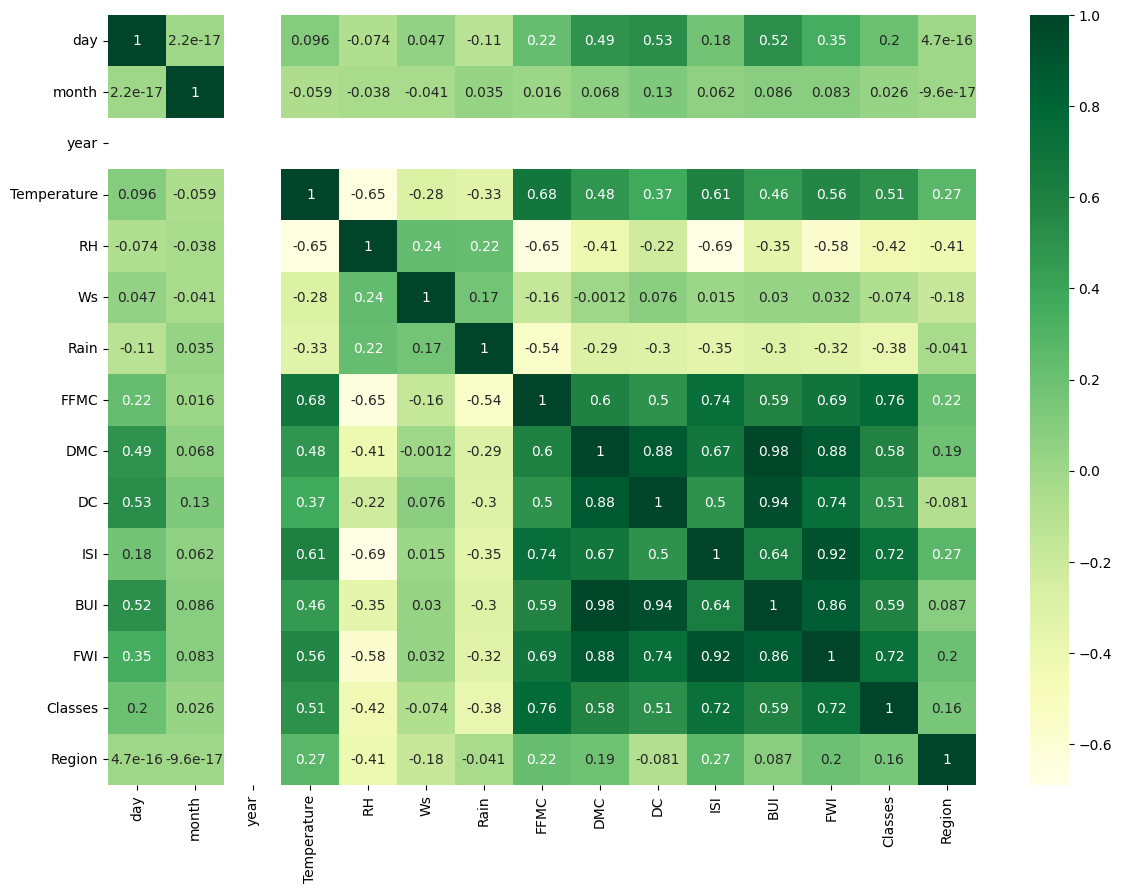

In [361]:
plt.figure(figsize=(14, 10))
sns.heatmap(corr, cmap = 'YlGn', annot = True)

In [362]:
data.columns

Index(['day', 'month', 'year', 'Temperature', 'RH', 'Ws', 'Rain', 'FFMC',
       'DMC', 'DC', 'ISI', 'BUI', 'FWI', 'Classes', 'Region'],
      dtype='object')

In [363]:
df_copy = data[['day', 'month','Temperature', 'RH', 'Ws', 'Rain', 'FFMC',
       'DMC', 'DC', 'ISI', 'BUI', 'FWI', 'Classes', 'Region']].copy()

In [364]:
df_copy.head()

,day,month,Temperature,RH,Ws,Rain,FFMC,DMC,DC,ISI,BUI,FWI,Classes,Region
0,1,6,29,57,18,0.0,65.7,3.4,7.6,1.3,3.4,0.5,0,0.0
1,2,6,29,61,13,1.3,64.4,4.1,7.6,1.0,3.9,0.4,0,0.0
2,3,6,26,82,22,13.1,47.1,2.5,7.1,0.3,2.7,0.1,0,0.0
3,4,6,25,89,13,2.5,28.6,1.3,6.9,0.0,1.7,0.0,0,0.0
4,5,6,27,77,16,0.0,64.8,3.0,14.2,1.2,3.9,0.5,0,0.0


In [366]:
plt.style.available

['Solarize_Light2',
 '_classic_test_patch',
 '_mpl-gallery',
 '_mpl-gallery-nogrid',
 'bmh',
 'classic',
 'dark_background',
 'fast',
 'fivethirtyeight',
 'ggplot',
 'grayscale',
 'petroff10',
 'seaborn-v0_8',
 'seaborn-v0_8-bright',
 'seaborn-v0_8-colorblind',
 'seaborn-v0_8-dark',
 'seaborn-v0_8-dark-palette',
 'seaborn-v0_8-darkgrid',
 'seaborn-v0_8-deep',
 'seaborn-v0_8-muted',
 'seaborn-v0_8-notebook',
 'seaborn-v0_8-paper',
 'seaborn-v0_8-pastel',
 'seaborn-v0_8-poster',
 'seaborn-v0_8-talk',
 'seaborn-v0_8-ticks',
 'seaborn-v0_8-white',
 'seaborn-v0_8-whitegrid',
 'tableau-colorblind10']

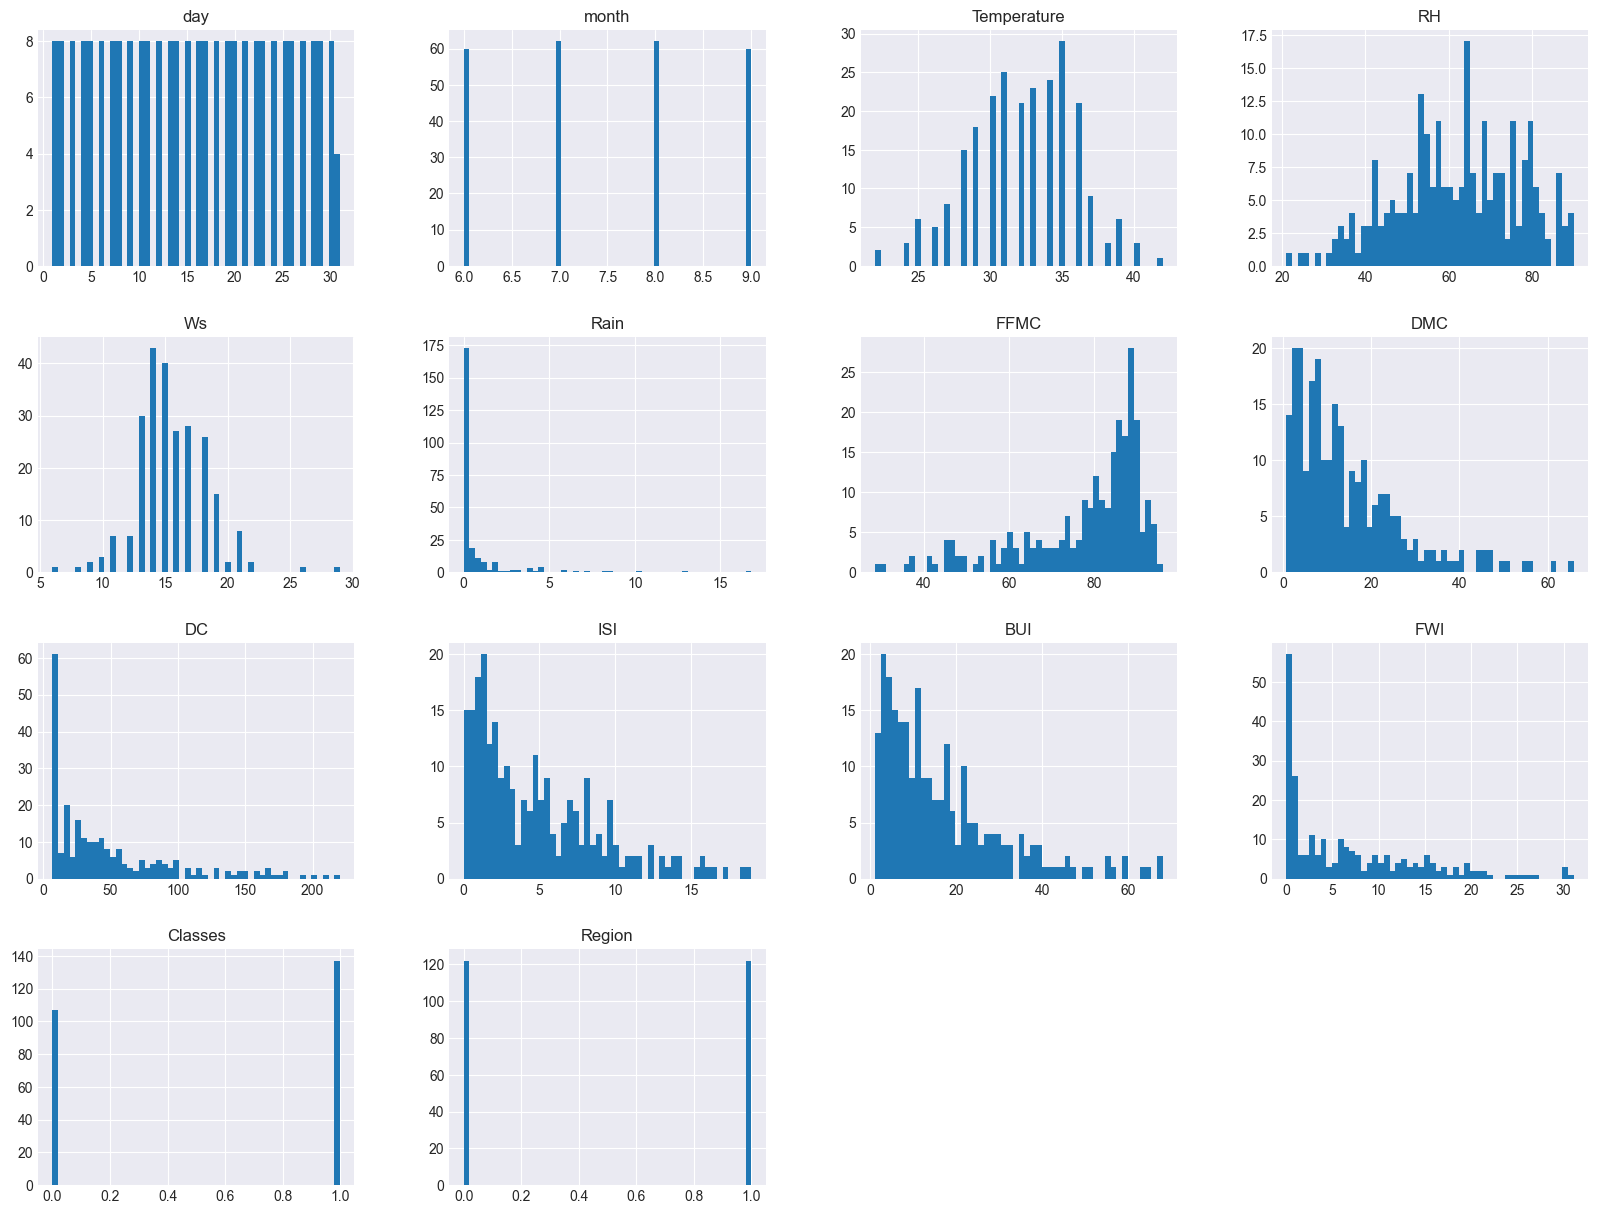

In [369]:
plt.style.use('seaborn-v0_8-dark')
df_copy.hist(bins = 50, figsize = (20, 15))
plt.show()

In [370]:
percentage = df_copy['Classes'].value_counts(normalize=True)*100

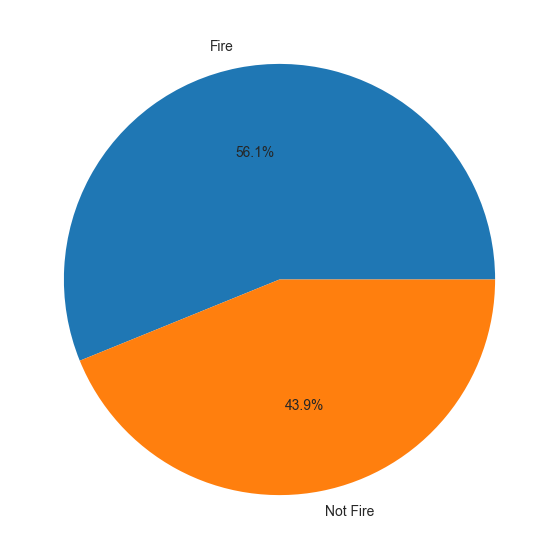

In [372]:
classes = ['Fire', 'Not Fire']
plt.figure(figsize = (10,7))
plt.pie(percentage,labels = classes, autopct = '%1.1f%%')
plt.show()

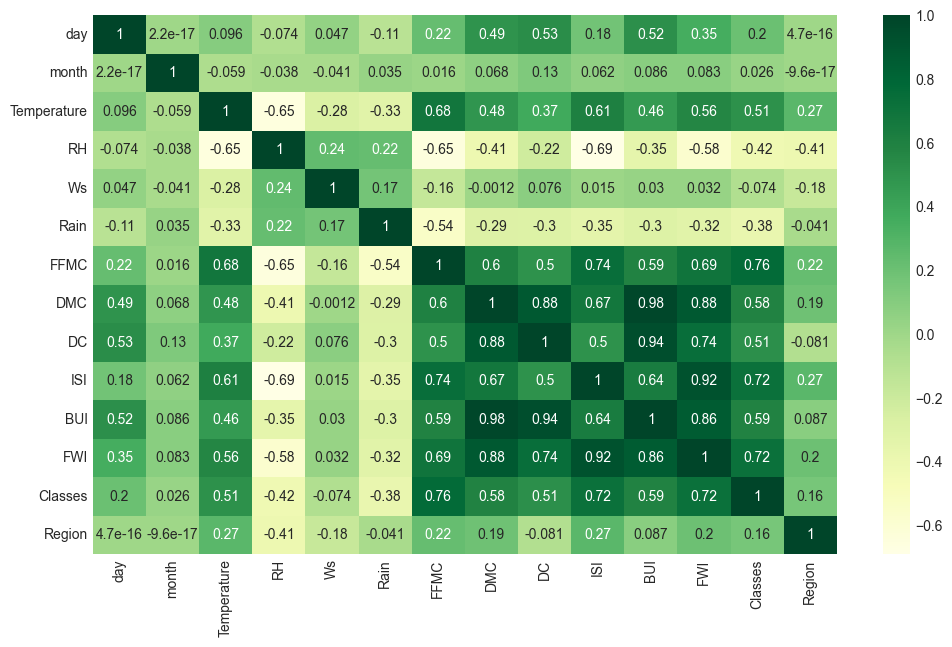

In [376]:
plt.figure(figsize=(12,7))
sns.heatmap(df_copy.corr(), cmap = 'YlGn', annot = True)
plt.show()

<Axes: >

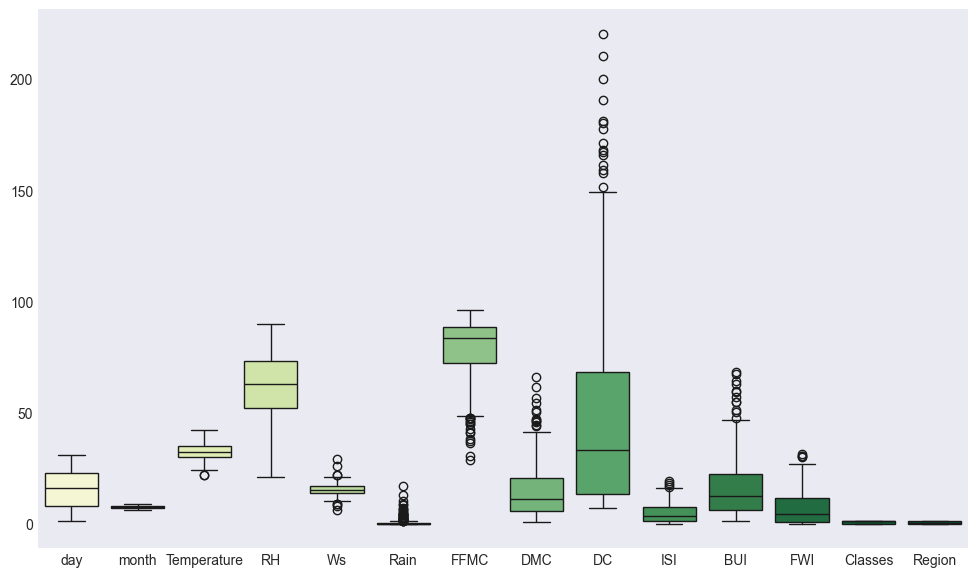

In [379]:
plt.figure(figsize=(12,7))
sns.boxplot(df_copy, palette = 'YlGn')

In [387]:
df['Region'].value_counts()

Region
0.0    122
1.0    122
Name: count, dtype: int64

Text(0.5, 1.0, 'Bajaia Region')

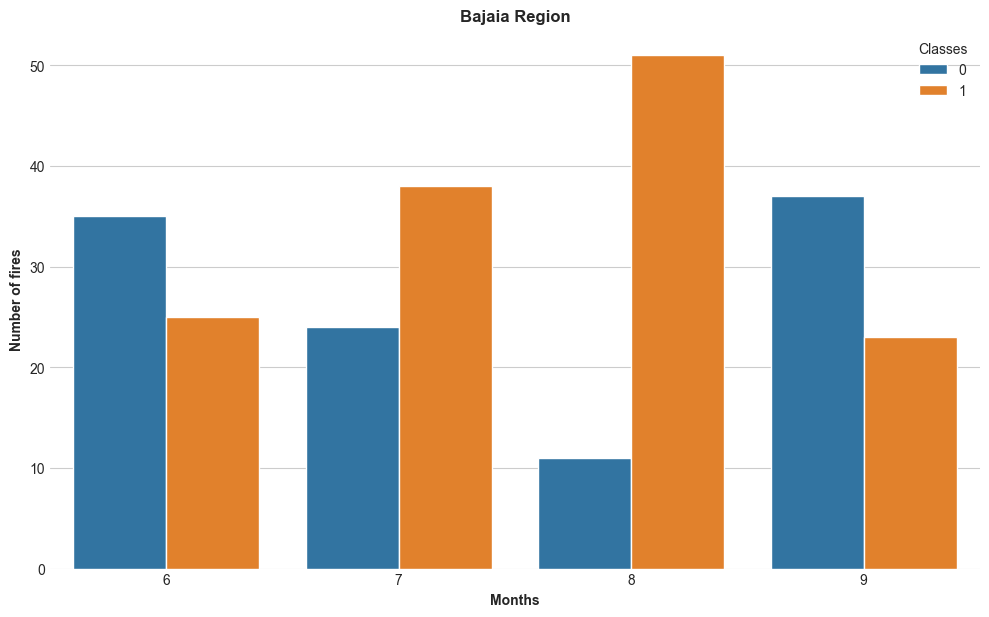

In [384]:
tmpval = df.loc[df['Region'] == 0]
plt.figure(figsize = (12,7))
sns.set_style('whitegrid')
sns.countplot(data = df,x = 'month', hue = 'Classes')
plt.ylabel('Number of fires', weight = 'bold')
plt.xlabel('Months', weight = 'bold')
plt.title("Bajaia Region", weight = 'bold')

Text(0.5, 1.0, 'Sidi-Bel Region')

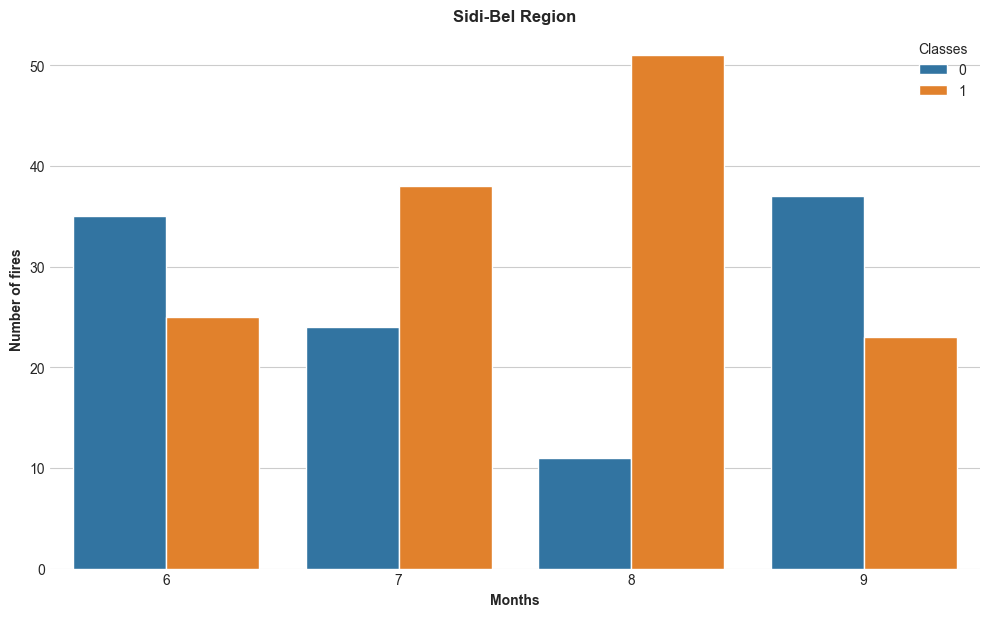

In [385]:
tmpval = df.loc[df['Region'] == 1]
plt.figure(figsize = (12,7))
sns.set_style('whitegrid')
sns.countplot(data = df,x = 'month', hue = 'Classes')
plt.ylabel('Number of fires', weight = 'bold')
plt.xlabel('Months', weight = 'bold')
plt.title("Sidi-Bel Region", weight = 'bold')

# Traing the Linear Models

In [12]:
data = pd.read_csv("../Datasets/Algerian_Forest/Forest_cleaned_dataset_Project.csv")

In [13]:
data.head(3)

,day,month,year,Temperature,RH,Ws,Rain,FFMC,DMC,DC,ISI,BUI,FWI,Classes,Region
0,1,6,2012,29,57,18,0.0,65.7,3.4,7.6,1.3,3.4,0.5,0,0.0
1,2,6,2012,29,61,13,1.3,64.4,4.1,7.6,1.0,3.9,0.4,0,0.0
2,3,6,2012,26,82,22,13.1,47.1,2.5,7.1,0.3,2.7,0.1,0,0.0


In [14]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 244 entries, 0 to 243
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   day          244 non-null    int64  
 1   month        244 non-null    int64  
 2   year         244 non-null    int64  
 3   Temperature  244 non-null    int64  
 4   RH           244 non-null    int64  
 5   Ws           244 non-null    int64  
 6   Rain         244 non-null    float64
 7   FFMC         244 non-null    float64
 8   DMC          244 non-null    float64
 9   DC           244 non-null    float64
 10  ISI          244 non-null    float64
 11  BUI          244 non-null    float64
 12  FWI          244 non-null    float64
 13  Classes      244 non-null    int64  
 14  Region       244 non-null    float64
dtypes: float64(8), int64(7)
memory usage: 28.7 KB


In [15]:
X = data.drop('FWI', axis = 1)
y = data['FWI']

In [16]:
X.head(3)

,day,month,year,Temperature,RH,Ws,Rain,FFMC,DMC,DC,ISI,BUI,Classes,Region
0,1,6,2012,29,57,18,0.0,65.7,3.4,7.6,1.3,3.4,0,0.0
1,2,6,2012,29,61,13,1.3,64.4,4.1,7.6,1.0,3.9,0,0.0
2,3,6,2012,26,82,22,13.1,47.1,2.5,7.1,0.3,2.7,0,0.0


In [17]:
X.drop(['day','month', 'year'], axis = 1, inplace = True)

In [18]:
X.head(3)

,Temperature,RH,Ws,Rain,FFMC,DMC,DC,ISI,BUI,Classes,Region
0,29,57,18,0.0,65.7,3.4,7.6,1.3,3.4,0,0.0
1,29,61,13,1.3,64.4,4.1,7.6,1.0,3.9,0,0.0
2,26,82,22,13.1,47.1,2.5,7.1,0.3,2.7,0,0.0


In [19]:
y

0      0.5
1      0.4
2      0.1
3      0.0
4      0.5
      ... 
239    6.5
240    0.0
241    0.2
242    0.7
243    0.5
Name: FWI, Length: 244, dtype: float64

In [20]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.25, random_state = 42)

In [22]:
X_train.shape, X_test.shape, y_train.shape, y_test.shape

((183, 11), (61, 11), (183,), (61,))

### Feature Selection based on correlation.

In [23]:
X_train.corr()

,Temperature,RH,Ws,Rain,FFMC,DMC,DC,ISI,BUI,Classes,Region
Temperature,1.000000,-0.664492,-0.249312,-0.375047,0.703238,0.485379,0.374689,0.609525,0.458575,0.497642,0.256099
RH,-0.664492,1.000000,0.235766,0.262550,-0.637201,-0.398168,-0.215094,-0.694976,-0.344365,-0.409824,-0.397053
Ws,-0.249312,0.235766,1.000000,0.262759,-0.169489,-0.013533,0.073933,0.015384,0.022529,-0.088098,-0.229797
Rain,-0.375047,0.262550,0.262759,1.000000,-0.585018,-0.291338,-0.296119,-0.353219,-0.301347,-0.390676,-0.096985
FFMC,0.703238,-0.637201,-0.169489,-0.585018,1.000000,0.602278,0.508360,0.744270,0.592841,0.764879,0.237434
DMC,0.485379,-0.398168,-0.013533,-0.291338,0.602278,1.000000,0.877050,0.652894,0.981876,0.581484,0.197489
DC,0.374689,-0.215094,0.073933,-0.296119,0.508360,0.877050,1.000000,0.496586,0.941251,0.508639,-0.079207
ISI,0.609525,-0.694976,0.015384,-0.353219,0.744270,0.652894,0.496586,1.000000,0.624038,0.723184,0.267027
BUI,0.458575,-0.344365,0.022529,-0.301347,0.592841,0.981876,0.941251,0.624038,1.000000,0.587278,0.092548
Classes,0.497642,-0.409824,-0.088098,-0.390676,0.764879,0.581484,0.508639,0.723184,0.587278,1.000000,0.147674


<Axes: >

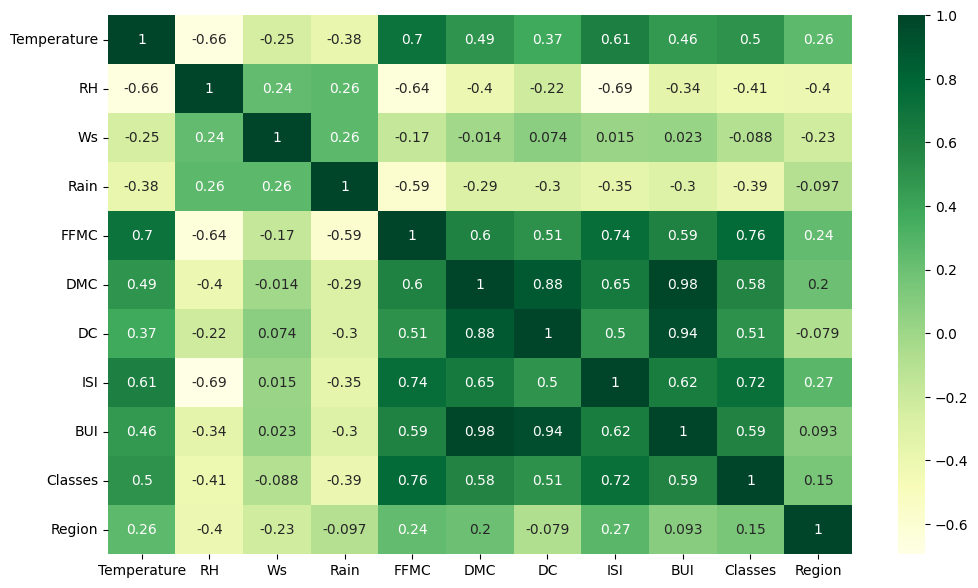

In [24]:
plt.figure(figsize = (12,7))
corr = X_train.corr()
sns.heatmap(corr, cmap = 'YlGn', annot = True)

##### We are now setting up a threshold value for correlation. And any columns having correlation greater than the threshold , then we should drop one of the columns.

In [25]:
def correlation(dataset, threshold):
    col_corr = set()
    corr_matrix = dataset.corr()
    for i in range(len(corr_matrix.columns)):
        for j in range(i):
            if abs(corr_matrix.iloc[i, j]) > threshold:
                col_name = corr_matrix.columns[i]
                col_corr.add(col_name)
    return col_corr

In [26]:
columns = correlation(X_train, 0.85)

In [27]:
print(columns)

{'DC', 'BUI'}


In [28]:
# We will drop these features
X_train.drop(columns, axis = 1, inplace = True)
X_test.drop(columns, axis = 1, inplace = True)
X_train.shape, X_test.shape

((183, 9), (61, 9))

#### Feature Scaling

In [29]:
from sklearn.preprocessing import StandardScaler

In [30]:
scale = StandardScaler()
X_train_s = scale.fit_transform(X_train)
X_test_s = scale.transform(X_test)

In [31]:
X_train_s

array([[-0.81085018,  0.16311382,  1.29231566, ..., -0.773495  ,
        -1.0976426 , -1.00547949],
       [ 1.06405791, -0.44884168,  0.15167049, ...,  0.83939993,
         0.91104336,  0.99455037],
       [-0.27516216,  0.63907922, -0.60875963, ..., -0.21981465,
         0.91104336,  0.99455037],
       ...,
       [-1.88222624,  0.91105944,  0.53188555, ..., -1.08644476,
        -1.0976426 , -1.00547949],
       [ 0.26052587, -0.38084663,  0.15167049, ...,  0.47830405,
         0.91104336,  0.99455037],
       [-0.54300617,  0.9790545 ,  2.05274578, ..., -0.86978723,
        -1.0976426 , -1.00547949]])

Text(0.5, 1.0, 'X_train_scaled')

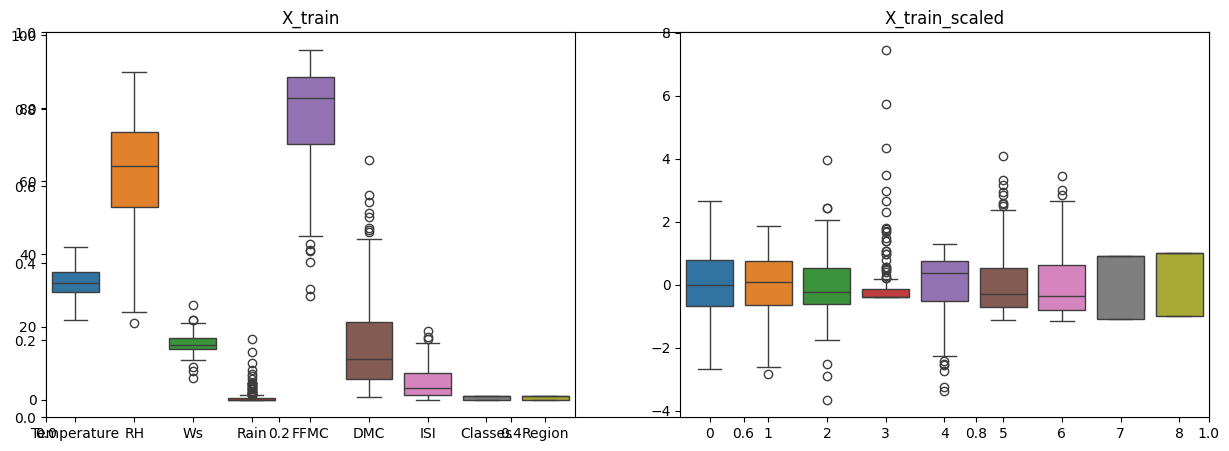

In [32]:
plt.subplots(figsize = (15,5))
plt.subplot(1, 2, 1)
sns.boxplot(data = X_train)
plt.title("X_train")
plt.subplot(1, 2, 2)
sns.boxplot(data = X_train_s)
plt.title("X_train_scaled")

# Linear Regression Model

The Mean Absolute Error :  0.626077792128666
The r2 score :  0.988214427147382


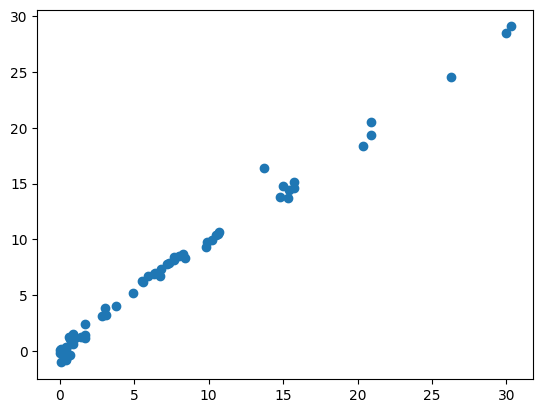

In [33]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, r2_score

model_linear = LinearRegression()
model_linear.fit(X_train_s, y_train)
y_pred = model_linear.predict(X_test_s)
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)
print('The Mean Absolute Error : ', mae)
print('The r2 score : ', r2)
plt.scatter(y_test, y_pred)

# Lasso Regression model

The Mean Absolute Error :  0.9571906603653757
The r2 score :  0.9708530650364495


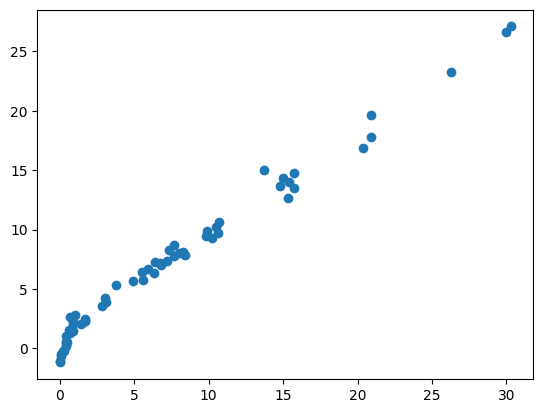

In [36]:
from sklearn.linear_model import Lasso
from sklearn.metrics import mean_absolute_error, r2_score

model_lasso = Lasso(alpha = 0.5)
model_lasso.fit(X_train_s, y_train)
y_pred = model_lasso.predict(X_test_s)
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)
print('The Mean Absolute Error : ', mae)
print('The r2 score : ', r2)
plt.scatter(y_test, y_pred)

# Cross Validation Lasso

In [37]:
from sklearn.linear_model import LassoCV

In [38]:
lasso_cv = LassoCV(cv = 5)
lasso_cv.fit(X_train_s, y_train)

,"eps eps: float, default=1e-3Length of the path. ``eps=1e-3`` means that``alpha_min / alpha_max = 1e-3``.",0.001
,"n_alphas n_alphas: int, default=100Number of alphas along the regularization path... deprecated:: 1.7 `n_alphas` was deprecated in 1.7 and will be removed in 1.9. Use `alphas` instead.",'deprecated'
,"alphas alphas: array-like or int, default=NoneValues of alphas to test along the regularization path.If int, `alphas` values are generated automatically.If array-like, list of alpha values to use... versionchanged:: 1.7 `alphas` accepts an integer value which removes the need to pass `n_alphas`... deprecated:: 1.7 `alphas=None` was deprecated in 1.7 and will be removed in 1.9, at which point the default value will be set to 100.",'warn'
,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto false, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"precompute precompute: 'auto', bool or array-like of shape (n_features, n_features), default='auto'Whether to use a precomputed Gram matrix to speed upcalculations. If set to ``'auto'`` let us decide. The Grammatrix can also be passed as argument.",'auto'
,"max_iter max_iter: int, default=1000The maximum number of iterations.",1000
,"tol tol: float, default=1e-4The tolerance for the optimization: if the updates are smaller or equal to``tol``, the optimization code checks the dual gap for optimality and continuesuntil it is smaller or equal to ``tol``.",0.0001
,"copy_X copy_X: bool, default=TrueIf ``True``, X will be copied; else, it may be overwritten.",True
,"cv cv: int, cross-validation generator or iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross-validation,- int, to specify the number of folds.- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For int/None inputs, :class:`~sklearn.model_selection.KFold` is used.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: bool or int, default=FalseAmount of verbosity.",False
,"n_jobs n_jobs: int, default=NoneNumber of CPUs to use during the cross validation.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.",None


In [39]:
lasso_cv.alpha_

0.03082368716183625

In [40]:
lasso_cv.alphas_

array([6.64076209, 6.19319695, 5.7757962 , 5.38652687, 5.02349299,
       4.68492637, 4.36917802, 4.07471004, 3.80008822, 3.54397499,
       3.30512294, 3.08236872, 2.87462738, 2.68088712, 2.5002043 ,
       2.3316989 , 2.17455019, 2.02799279, 1.89131286, 1.76384471,
       1.64496748, 1.53410217, 1.43070882, 1.33428384, 1.24435757,
       1.16049203, 1.08227876, 1.00933679, 0.94131087, 0.87786967,
       0.81870419, 0.76352627, 0.71206715, 0.66407621, 0.6193197 ,
       0.57757962, 0.53865269, 0.5023493 , 0.46849264, 0.4369178 ,
       0.407471  , 0.38000882, 0.3543975 , 0.33051229, 0.30823687,
       0.28746274, 0.26808871, 0.25002043, 0.23316989, 0.21745502,
       0.20279928, 0.18913129, 0.17638447, 0.16449675, 0.15341022,
       0.14307088, 0.13342838, 0.12443576, 0.1160492 , 0.10822788,
       0.10093368, 0.09413109, 0.08778697, 0.08187042, 0.07635263,
       0.07120672, 0.06640762, 0.06193197, 0.05775796, 0.05386527,
       0.05023493, 0.04684926, 0.04369178, 0.0407471 , 0.03800

In [41]:
lasso_cv.mse_path_

array([[58.58419754, 43.76850724, 54.61786113, 72.91709755, 37.03534792],
       [53.59568439, 39.22807509, 50.06806283, 69.7558873 , 32.61350576],
       [48.06413432, 34.67365526, 43.74573369, 63.755404  , 28.59114109],
       [42.47683898, 30.68917059, 38.14919682, 58.44720076, 24.57314067],
       [37.5967684 , 27.20196564, 33.28314049, 53.74712517, 21.15421184],
       [33.33348763, 24.14871678, 29.05223641, 49.5815802 , 18.25113147],
       [29.60776131, 21.4742727 , 25.37351288, 45.17972024, 15.79171856],
       [26.35076814, 19.13056643, 22.17526555, 39.92015804, 13.71423104],
       [23.50257035, 17.07570596, 19.39468306, 35.32157143, 11.9645469 ],
       [21.01096194, 15.27319427, 16.97729067, 31.29924144, 10.49611363],
       [18.83024326, 13.69115992, 14.87571399, 27.77964082,  9.26870222],
       [16.92126799, 12.30186476, 13.04875382, 24.69871622,  8.24756589],
       [15.24926587, 11.0811022 , 11.46040601, 22.00004964,  7.40252405],
       [13.78415751, 10.00775807, 10.0

The Mean Absolute Error :  0.6646912098947267
The r2 score :  0.9872924101396543


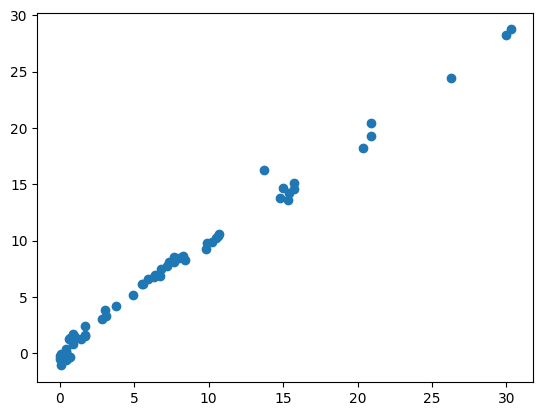

In [42]:
y_pred = lasso_cv.predict(X_test_s)
plt.scatter(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)
print('The Mean Absolute Error : ', mae)
print('The r2 score : ', r2)

# Ridge Regression Model

The Mean Absolute Error :  0.6464137712540032
The r2 score :  0.9874737072473474


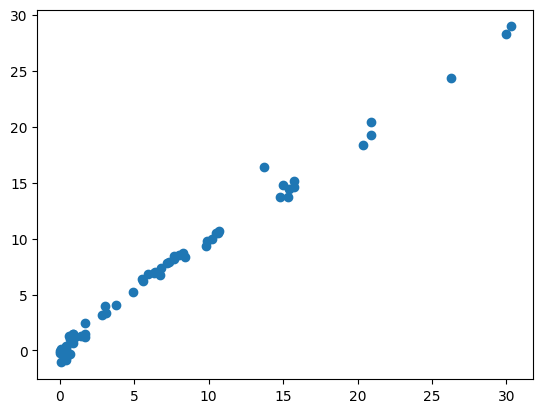

In [43]:
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_absolute_error, r2_score

model_ridge = Ridge()
model_ridge.fit(X_train_s, y_train)
y_pred = model_ridge.predict(X_test_s)
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)
print('The Mean Absolute Error : ', mae)
print('The r2 score : ', r2)
plt.scatter(y_test, y_pred)

The Mean Absolute Error :  0.6464137712540032
The r2 score :  0.9874737072473474


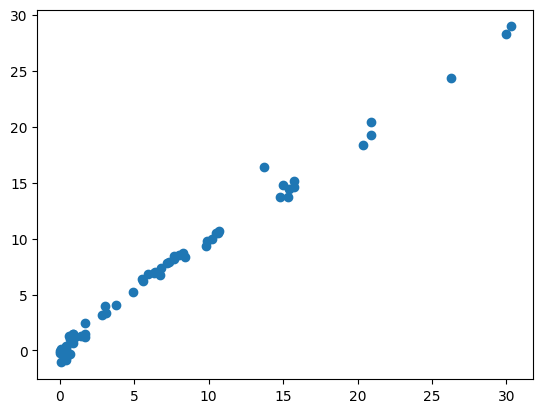

In [44]:
from sklearn.linear_model import RidgeCV
from sklearn.metrics import mean_absolute_error, r2_score

model_ridge_cv = RidgeCV(cv = 5)
model_ridge_cv.fit(X_train_s, y_train)
y_pred = model_ridge_cv.predict(X_test_s)
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)
print('The Mean Absolute Error : ', mae)
print('The r2 score : ', r2)
plt.scatter(y_test, y_pred)

In [45]:
model_ridge_cv.get_params()

{'alpha_per_target': False,
 'alphas': (0.1, 1.0, 10.0),
 'cv': 5,
 'fit_intercept': True,
 'gcv_mode': None,
 'scoring': None,
 'store_cv_results': False}

# ElasticNet Model

The Mean Absolute Error :  1.9175981288141104
The r2 score :  0.8752711247961272


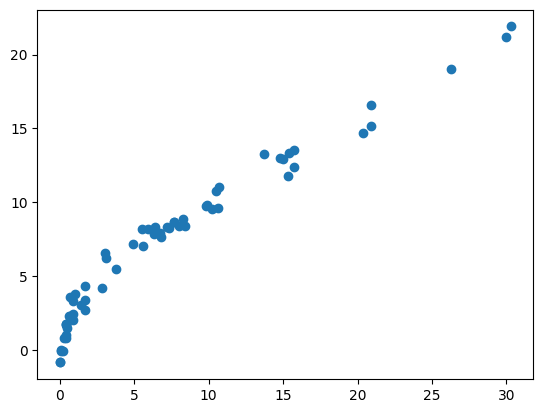

In [46]:
from sklearn.linear_model import ElasticNet
from sklearn.metrics import mean_absolute_error, r2_score

model_elastic = ElasticNet()
model_elastic.fit(X_train_s, y_train)
y_pred = model_elastic.predict(X_test_s)
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)
print('The Mean Absolute Error : ', mae)
print('The r2 score : ', r2)
plt.scatter(y_test, y_pred)

The Mean Absolute Error :  0.6616282910488148
The r2 score :  0.9871542613898666


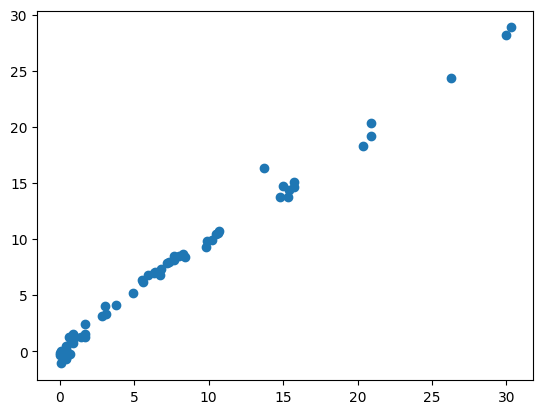

In [47]:
from sklearn.linear_model import ElasticNetCV
from sklearn.metrics import mean_absolute_error, r2_score

model_elastic_cv = ElasticNetCV(cv=5)
model_elastic_cv.fit(X_train_s, y_train)
y_pred = model_elastic_cv.predict(X_test_s)
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)
print('The Mean Absolute Error : ', mae)
print('The r2 score : ', r2)
plt.scatter(y_test, y_pred)

# Pickle the Machine Learning Model, and StandardScaler model

In [49]:
scale

,"copy copy: bool, default=TrueIf False, try to avoid a copy and do inplace scaling instead.This is not guaranteed to always work inplace; e.g. if the data isnot a NumPy array or scipy.sparse CSR matrix, a copy may still bereturned.",True
,"with_mean with_mean: bool, default=TrueIf True, center the data before scaling.This does not work (and will raise an exception) when attempted onsparse matrices, because centering them entails building a densematrix which in common use cases is likely to be too large to fit inmemory.",True
,"with_std with_std: bool, default=TrueIf True, scale the data to unit variance (or equivalently,unit standard deviation).",True


In [50]:
model_ridge

,"alpha alpha: {float, ndarray of shape (n_targets,)}, default=1.0Constant that multiplies the L2 term, controlling regularizationstrength. `alpha` must be a non-negative float i.e. in `[0, inf)`.When `alpha = 0`, the objective is equivalent to ordinary leastsquares, solved by the :class:`LinearRegression` object. For numericalreasons, using `alpha = 0` with the `Ridge` object is not advised.Instead, you should use the :class:`LinearRegression` object.If an array is passed, penalties are assumed to be specific to thetargets. Hence they must correspond in number.",1.0
,"fit_intercept fit_intercept: bool, default=TrueWhether to fit the intercept for this model. If setto false, no intercept will be used in calculations(i.e. ``X`` and ``y`` are expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"max_iter max_iter: int, default=NoneMaximum number of iterations for conjugate gradient solver.For 'sparse_cg' and 'lsqr' solvers, the default value is determinedby scipy.sparse.linalg. For 'sag' solver, the default value is 1000.For 'lbfgs' solver, the default value is 15000.",None
,"tol tol: float, default=1e-4The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for each solver:- 'svd': `tol` has no impact.- 'cholesky': `tol` has no impact.- 'sparse_cg': norm of residuals smaller than `tol`.- 'lsqr': `tol` is set as atol and btol of scipy.sparse.linalg.lsqr, which control the norm of the residual vector in terms of the norms of matrix and coefficients.- 'sag' and 'saga': relative change of coef smaller than `tol`.- 'lbfgs': maximum of the absolute (projected) gradient=max|residuals| smaller than `tol`... versionchanged:: 1.2 Default value changed from 1e-3 to 1e-4 for consistency with other linear models.",0.0001
,"solver solver: {'auto', 'svd', 'cholesky', 'lsqr', 'sparse_cg', 'sag', 'saga', 'lbfgs'}, default='auto'Solver to use in the computational routines:- 'auto' chooses the solver automatically based on the type of data.- 'svd' uses a Singular Value Decomposition of X to compute the Ridge coefficients. It is the most stable solver, in particular more stable for singular matrices than 'cholesky' at the cost of being slower.- 'cholesky' uses the standard :func:`scipy.linalg.solve` function to obtain a closed-form solution.- 'sparse_cg' uses the conjugate gradient solver as found in :func:`scipy.sparse.linalg.cg`. As an iterative algorithm, this solver is more appropriate than 'cholesky' for large-scale data (possibility to set `tol` and `max_iter`).- 'lsqr' uses the dedicated regularized least-squares routine :func:`scipy.sparse.linalg.lsqr`. It is the fastest and uses an iterative procedure.- 'sag' uses a Stochastic Average Gradient descent, and 'saga' uses its improved, unbiased version named SAGA. Both methods also use an iterative procedure, and are often faster than other solvers when both n_samples and n_features are large. Note that 'sag' and 'saga' fast convergence is only guaranteed on features with approximately the same scale. You can preprocess the data with a scaler from :mod:`sklearn.preprocessing`.- 'lbfgs' uses L-BFGS-B algorithm implemented in :func:`scipy.optimize.minimize`. It can be used only when `positive` is True.All solvers except 'svd' support both dense and sparse data. However, only'lsqr', 'sag', 'sparse_cg', and 'lbfgs' support sparse input when`fit_intercept` is True... versionadded:: 0.17 Stochastic Average Gradient descent solver... versionadded:: 0.19 SAGA solver.",'auto'
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive.Only 'lbfgs' solver is supported in this case.",False
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag' or 'saga' to shuffle the data.See :term:`Glossary ` for details... versionadded:: 0.17 `random_state` to support Stochastic Average Gradient.",None


In [51]:
import pickle

In [52]:
pickle.dump(scale, open('scaler.pkl', 'wb'))

In [53]:
pickle.dump(model_ridge, open('ridge.pkl', 'wb'))